<a href="https://colab.research.google.com/github/TriSatriaPamungkas/NaturalLanguageProcessing/blob/main/Bank_UTS_NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install pandas nltk sastrawi scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 6.9 MB/s eta 0:00:00


In [33]:
import pandas as pd
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
from nltk.corpus import stopwords

In [35]:
# NLTK untuk tokenization
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [36]:
# 1. Inisialisasi Sastrawi untuk bahasa Indonesia
stemmer_en = PorterStemmer()
stop_words_en = set(stopwords.words('english'))

In [37]:
# 2. Muat Dataset
df = pd.read_csv('banking_knowledge_base_1000.csv', sep=',')

In [42]:
# 3. Text Preprocessing
def text_preprocessing(text):
    # a. Text Cleaning
    text_clean = str(text).lower()
    text_clean = re.sub(r'[^a-z\s]', '', text_clean)

    # b. Tokenization
    tokens = word_tokenize(text_clean)

    # c. Stopword Removal & d. Stemming

    processed_tokens = [stemmer_en.stem(word) for word in tokens if word not in stop_words_en]

    return ' '.join(processed_tokens)

In [43]:
print("Memulai proses Text Preprocessing. Ini mungkin memakan waktu beberapa saat...")
df['CleanQuestion'] = df['Question'].apply(text_preprocessing)

Memulai proses Text Preprocessing. Ini mungkin memakan waktu beberapa saat...


In [44]:
# 5. Tampilkan hasil perbandingan teks asli dan teks bersih
print("\n=== HASIL TEXT PREPROCESSING ===")
display(df[['Question', 'CleanQuestion']].head(10))


=== HASIL TEXT PREPROCESSING ===


,Question,CleanQuestion
0,What is a Savings Account?,save account
1,What is a Current Account?,current account
2,What is a Fixed Deposit?,fix deposit
3,What does KYC stand for?,kyc stand
4,What is a cheque?,chequ
5,What happens when a cheque bounces?,happen chequ bounc
6,What is a Demand Draft?,demand draft
7,What is an overdraft?,overdraft
8,What is a joint account?,joint account
9,What is a nominee in a bank account?,nomine bank account


In [45]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [46]:
#  VEKTOR (BoW & TF-IDF)

# a. Inisialisasi Vectorizer
# Bag-of-Words (BoW)
vectorizer_bow = CountVectorizer()
X_bow = vectorizer_bow.fit_transform(df['CleanQuestion'])

# TF-IDF
vectorizer_tfidf = TfidfVectorizer()
X_tfidf = vectorizer_tfidf.fit_transform(df['CleanQuestion'])

print("Tahap Representasi Vektor Selesai.")
print(f"Dimensi Matriks BoW: {X_bow.shape}")
print(f"Dimensi Matriks TF-IDF: {X_tfidf.shape}\n")

Tahap Representasi Vektor Selesai.
Dimensi Matriks BoW: (1000, 892)
Dimensi Matriks TF-IDF: (1000, 892)



In [53]:
def tanya_chatbot(User_Query):
    print(f"Pertanyaan Anda: '{User_Query}'\n")

    # 1. Preprocessing input user
    CleanQuery = text_preprocessing(User_Query)

    # 2. Vektorisasi input user
    query_vec_bow = vectorizer_bow.transform([CleanQuery])
    query_vec_tfidf = vectorizer_tfidf.transform([CleanQuery])

    # 3. Hitung Cosine Similarity
    sim_bow = cosine_similarity(query_vec_bow, X_bow).flatten()
    sim_tfidf = cosine_similarity(query_vec_tfidf, X_tfidf).flatten()

    # 4. Ambil index dokumen dengan skor tertinggi
    best_idx_bow = sim_bow.argmax()
    best_idx_tfidf = sim_tfidf.argmax()

    best_score_bow = sim_bow[best_idx_bow]
    best_score_tfidf = sim_tfidf[best_idx_tfidf]

    # 5. Tampilkan Hasil
    print("--- HASIL BAG-OF-WORDS (BoW) ---")
    print(f"Skor Kemiripan : {best_score_bow:.4f}")
    print(f"Pertanyaan     : {df['Question'].iloc[best_idx_bow]}")
    print(f"Jawaban        : {df['Answer'].iloc[best_idx_bow]}\n")

    print("--- HASIL TF-IDF ---")
    print(f"Skor Kemiripan : {best_score_tfidf:.4f}")
    print(f"Pertanyaan     : {df['Question'].iloc[best_idx_tfidf]}")
    print(f"Jawaban        : {df['Answer'].iloc[best_idx_tfidf]}\n")

    return sim_bow, sim_tfidf, best_idx_bow, best_idx_tfidf

In [54]:
# TAHAP 4.5: SIMULASI CHATBOT INTERAKTIF

print("="*50)
print("WELCOME TO THE VIRTUAL COMMUNITY ASSISTANT")
print("Type 'exit', 'quit', or 'stop' to end the session.")
print("="*50)

while True:
    # input
    User_Query = input("\nAnda: ")

    # Cek apakah pengguna ingin keluar dari program
    if User_Query.lower() in [ 'exit', 'stop', 'quit']:
        print("Chatbot: Thank you for using our service. See you!")
        break

    # Cek jika input kosong (hanya menekan enter)
    if not User_Query.strip():
        print("Chatbot: Question cannot be empty. Please type something.")
        continue

    sim_bow, sim_tfidf, best_idx_bow, best_idx_tfidf = tanya_chatbot(User_Query)

    print("-" * 50)


WELCOME TO THE VIRTUAL COMMUNITY ASSISTANT
Type 'exit', 'quit', or 'stop' to end the session.

Anda: banks
Pertanyaan Anda: 'banks'

--- HASIL BAG-OF-WORDS (BoW) ---
Skor Kemiripan : 0.7559
Pertanyaan     : What is the difference between bank credit and bank debit?
Jawaban        : In banking, a credit is money added to your account (deposit, transfer received). A debit is money taken from your account (withdrawal, EMI, fee).

--- HASIL TF-IDF ---
Skor Kemiripan : 0.5278
Pertanyaan     : What is the difference between bank credit and bank debit?
Jawaban        : In banking, a credit is money added to your account (deposit, transfer received). A debit is money taken from your account (withdrawal, EMI, fee).

--------------------------------------------------

Anda: bank
Pertanyaan Anda: 'bank'

--- HASIL BAG-OF-WORDS (BoW) ---
Skor Kemiripan : 0.7559
Pertanyaan     : What is the difference between bank credit and bank debit?
Jawaban        : In banking, a credit is money added to your a

/tmp/ipykernel_4548/4111708816.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frekuensi', y='Word', data=df_freq, palette='viridis')


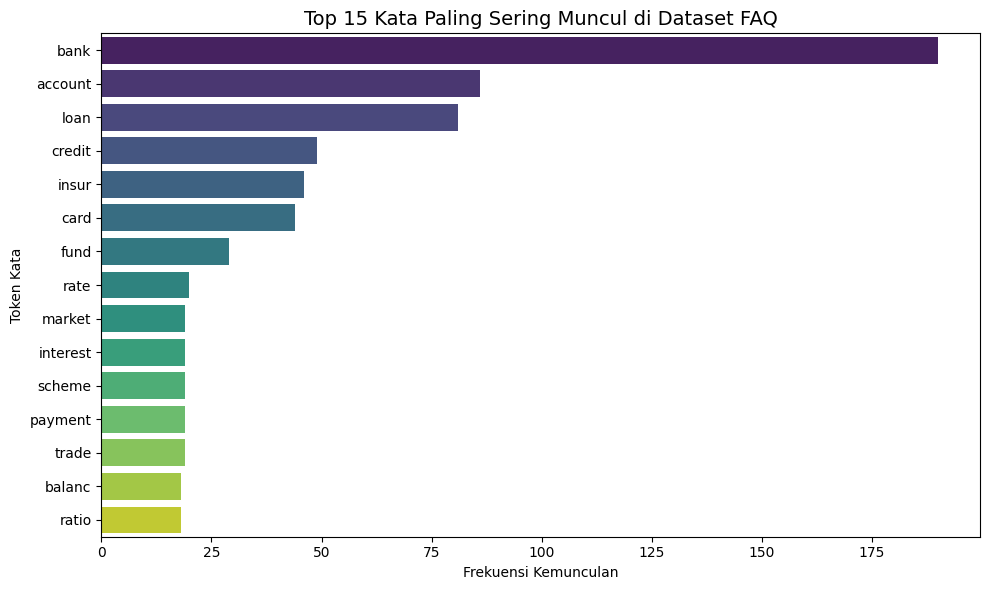

In [55]:
# TAHAP 5: VISUALISASI DATA

# Visualisasi 1: Distribusi 15 Kata Teratas (Berdasarkan BoW)
kata_kata = vectorizer_bow.get_feature_names_out()
frekuensi = X_bow.toarray().sum(axis=0)

df_freq = pd.DataFrame({'Word': kata_kata, 'Frekuensi': frekuensi})
df_freq = df_freq.sort_values(by='Frekuensi', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x='Frekuensi', y='Word', data=df_freq, palette='viridis')
plt.title('Top 15 Kata Paling Sering Muncul di Dataset FAQ', fontsize=14)
plt.xlabel('Frekuensi Kemunculan')
plt.ylabel('Token Kata')
plt.tight_layout()
plt.show()

Pertanyaan Anda: 'What is an account?'

--- HASIL BAG-OF-WORDS (BoW) ---
Skor Kemiripan : 0.7071
Pertanyaan     : What is a Savings Account?
Jawaban        : A savings account lets you keep your money safe in a bank while earning a small interest, usually around 2–4% per year.

--- HASIL TF-IDF ---
Skor Kemiripan : 0.5739
Pertanyaan     : What is a trading account?
Jawaban        : A trading account is used to place buy and sell orders in the stock market. It works alongside a demat account.



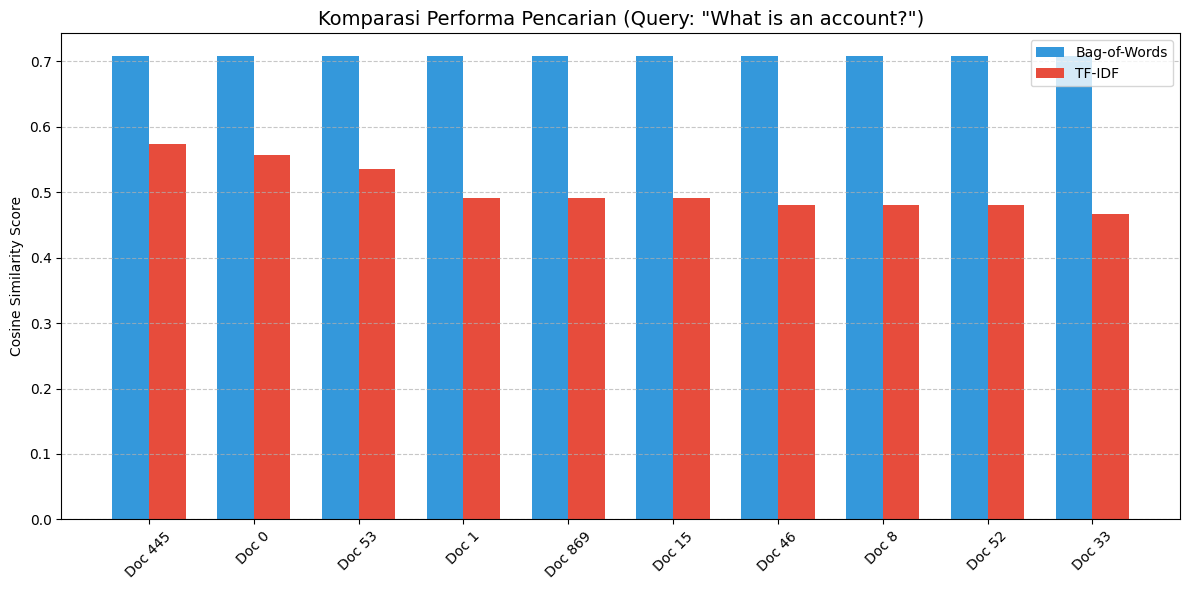

In [56]:
# Visualisasi 2: Perbandingan Skor Cosine Similarity (BoW vs TF-IDF)

# Untuk mendapatkan skor_bow, skor_tfidf, dan pertanyaan_test untuk visualisasi,
# kita perlu menjalankan fungsi tanya_chatbot sekali dengan sebuah query.
pertanyaan_test = "What is an account?"
sim_bow_result, sim_tfidf_result, _, _ = tanya_chatbot(pertanyaan_test)

skor_bow = sim_bow_result
skor_tfidf = sim_tfidf_result

# Mengambil 10 dokumen dengan skor tertinggi dari pencarian TF-IDF untuk dibandingkan
top_10_idx = skor_tfidf.argsort()[-10:][::-1]
skor_bow_top10 = skor_bow[top_10_idx]
skor_tfidf_top10 = skor_tfidf[top_10_idx]

x_labels = [f"Doc {i}" for i in top_10_idx]
x = np.arange(len(x_labels))
width = 0.35

plt.figure(figsize=(12, 6))
plt.bar(x - width/2, skor_bow_top10, width, label='Bag-of-Words', color='#3498db')
plt.bar(x + width/2, skor_tfidf_top10, width, label='TF-IDF', color='#e74c3c')

plt.ylabel('Cosine Similarity Score')
plt.title(f'Komparasi Performa Pencarian (Query: "{pertanyaan_test}")', fontsize=14)
plt.xticks(x, x_labels, rotation=45)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
